# Week 6: Advanced Python Analysis – Apple (AAPL) Stock Market Analysis

## Internship Project – AnalystLab Africa

### Objective
This project applies advanced Python techniques for data transformation,
time-series analysis, and feature engineering using historical Apple Inc.
(AAPL) stock market data.

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- yfinance
- Google Colab

### Analysis Areas
- Data cleaning and preprocessing
- Advanced Pandas data transformation
- Time-series analysis
- Moving averages
- Percentage returns
- Volatility analysis
- Feature engineering
- Data visualization

## 1. Environment Setup

This section imports the Python libraries required for data collection,
data manipulation, statistical analysis, and visualization.

In [2]:
!pip install yfinance

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Collection

Historical stock market data for Apple Inc. (AAPL) was collected directly
from Yahoo Finance using the `yfinance` Python library.

The analysis covers trading data from January 2020 to July 2026.

In [4]:
aapl = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2026-08-01",
    auto_adjust=False
)

print("Data downloaded successfully.")

[*********************100%***********************]  1 of 1 completed

Data downloaded successfully.


In [5]:
print("Dataset Shape:", aapl.shape)

Dataset Shape: (1653, 6)


In [6]:
aapl.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2020-01-02,72.271523,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,72.954910,75.797501,76.110001,74.290001,74.290001,132079200


## 3. Data Exploration

The dataset is examined to understand its structure, dimensions, data types,
date range, and the available stock market variables before preprocessing.

## 4. Data Cleaning & Preprocessing

The dataset is cleaned and prepared for analysis by simplifying the column
structure, formatting the date index, checking for missing values and
duplicates, validating numerical values, and sorting the observations
chronologically.

In [7]:
print("Dataset Shape:", aapl.shape)

print("\nColumn Structure:")
print(aapl.columns)

print("\nData Types:")
print(aapl.dtypes)

Dataset Shape: (1653, 6)

Column Structure:
MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

Data Types:
Price      Ticker
Adj Close  AAPL      float64
Close      AAPL      float64
High       AAPL      float64
Low        AAPL      float64
Open       AAPL      float64
Volume     AAPL        int64
dtype: object


In [8]:
# Remove the ticker level from the column index
aapl.columns = aapl.columns.droplevel(1)

print(aapl.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [9]:
df = aapl.copy()

print("Working dataset created successfully.")
print("Shape:", df.shape)

Working dataset created successfully.
Shape: (1653, 6)


In [10]:
df.index = pd.to_datetime(df.index)

print("Index Type:", type(df.index))
print("Start Date:", df.index.min())
print("End Date:", df.index.max())

Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Start Date: 2020-01-02 00:00:00
End Date: 2026-07-31 00:00:00


In [11]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [13]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,1653.000000,1653.000000,1653.000000,1653.000000,1653.000000,1.653000e+03
mean,174.648668,177.028978,178.852394,175.030053,176.848034,8.160928e+07
std,58.069910,57.250683,57.683454,56.752441,57.165929,5.046374e+07
min,54.117027,56.092499,57.125000,53.152500,57.020000,1.791060e+07
25%,135.551620,138.339996,140.759995,136.539993,138.050003,4.882250e+07
50%,168.493149,171.660004,173.190002,170.000000,171.190002,6.725300e+07
75%,216.935669,218.800003,221.479996,216.580002,218.929993,9.681350e+07
max,339.786926,340.079987,344.570007,337.350006,340.029999,4.265100e+08


In [14]:
print("Non-positive Open prices:", (df["Open"] <= 0).sum())
print("Non-positive Close prices:", (df["Close"] <= 0).sum())
print("Non-positive High prices:", (df["High"] <= 0).sum())
print("Non-positive Low prices:", (df["Low"] <= 0).sum())
print("Non-positive Volume:", (df["Volume"] <= 0).sum())

Non-positive Open prices: 0
Non-positive Close prices: 0
Non-positive High prices: 0
Non-positive Low prices: 0
Non-positive Volume: 0


In [15]:
df = df.sort_index()

print("Data sorted chronologically.")

Data sorted chronologically.


In [16]:
print("Final Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (1653, 6)

Columns:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Missing Values:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Duplicate Rows: 0


## 5. Data Transformation with Pandas

In this section, Pandas is used to transform the cleaned stock market
dataset into a format suitable for deeper analysis.

The transformation process includes filtering, sorting, grouping,
aggregation, and the creation of calculated variables.

### 5.1 Creating Date-Based Features

The original dataset uses the trading date as its index. To support
time-based grouping and analysis, additional date features are extracted
from the index.

The following features will be created:
- Year
- Month
- Month Name
- Day of Week

These features will later be used for monthly aggregation and time-series
analysis.

In [17]:
df["Year"] = df.index.year
df["Month"] = df.index.month
df["Month_Name"] = df.index.month_name()
df["Day_of_Week"] = df.index.day_name()

df.head()

Price,Adj Close,Close,High,Low,Open,Volume,Year,Month,Month_Name,Day_of_Week
Date,,,,,,,,,,
2020-01-02,72.271523,75.087502,75.150002,73.797501,74.059998,135480400,2020,1,January,Thursday
2020-01-03,71.568924,74.357498,75.144997,74.125000,74.287498,146322800,2020,1,January,Friday
2020-01-06,72.139191,74.949997,74.989998,73.187500,73.447502,118387200,2020,1,January,Monday
2020-01-07,71.799919,74.597504,75.224998,74.370003,74.959999,108872000,2020,1,January,Tuesday
2020-01-08,72.954910,75.797501,76.110001,74.290001,74.290001,132079200,2020,1,January,Wednesday


### Interpretation

The date transformation was completed successfully. The original trading
date was used to create four additional time-based features: Year, Month,
Month_Name, and Day_of_Week.

For example, the first observation, dated January 2, 2020, was correctly
identified as belonging to the year 2020, month 1 (January), and Thursday.

These features will allow the dataset to be grouped and analyzed across
different months, years, and trading days.

### 5.2 Filtering Trading Days

Filtering is used to select specific observations that satisfy a given
condition.

In this analysis, we will identify trading days on which Apple's closing
price was higher than the overall average closing price. This helps us
understand how often the stock traded above its average closing level during
the study period.

In [18]:
average_close = df["Close"].mean()

print(f"Average Closing Price: ${average_close:.2f}")

above_average = df[df["Close"] > average_close]

print("Trading days above average:", len(above_average))

above_average.head()

Average Closing Price: $177.03
Trading days above average: 732


Price,Adj Close,Close,High,Low,Open,Volume,Year,Month,Month_Name,Day_of_Week
Date,,,,,,,,,,
2021-12-10,175.285782,179.449997,179.630005,174.690002,175.210007,115402700,2021,12,December,Friday
2021-12-15,175.139282,179.300003,179.500000,172.309998,175.110001,131063300,2021,12,December,Wednesday
2021-12-27,176.145355,180.330002,180.419998,177.070007,177.089996,74919600,2021,12,December,Monday
2021-12-28,175.129501,179.289993,181.330002,178.529999,180.160004,79144300,2021,12,December,Tuesday
2021-12-29,175.217438,179.380005,180.630005,178.139999,179.330002,62348900,2021,12,December,Wednesday


### Interpretation

The average closing price of Apple (AAPL) during the study period was
$177.03.

Out of the 1,653 trading days analyzed, 732 days recorded a closing price
above this average. This represents approximately 44.3% of the trading
days.

The result shows that the stock spent a substantial portion of the study
period above its overall average closing price, while the remaining trading
days were below the average. This provides an initial indication of the
variation in Apple's stock price over the study period.

### 5.3 Sorting Stock Market Data

Sorting is used to rank observations according to a specific variable.

In this analysis, the data will be sorted by closing price to identify the
10 trading days with the highest closing prices. The data will also be
sorted by trading volume to identify the days when the stock experienced
the highest level of market activity.

This helps identify periods of unusually high prices and trading activity.

In [19]:
top_10_closing_prices = df.sort_values(
    by="Close",
    ascending=False
).head(10)

top_10_closing_prices[["Close", "Volume"]]

Price,Close,Volume
Date,,
2026-07-28,340.079987,51859000
2026-07-29,338.190002,56090800
2026-07-27,336.910004,49604300
2026-07-17,333.739990,63407100
2026-07-30,333.429993,74817800
2026-07-16,333.260010,62970600
2026-07-24,333.019989,47489400
2026-07-21,327.739990,41338900
2026-07-15,327.500000,60957600


### Interpretation

The sorting analysis shows that the 10 highest closing prices in the
dataset occurred during July 2026.

The highest recorded closing price was $340.08 on July 28, 2026, followed
by $338.19 on July 29, 2026. The remaining observations in the top 10 also
occurred during July 2026, with closing prices ranging from approximately
$326.59 to $336.91.

This concentration of the highest closing prices toward the end of the
study period indicates a strong upward movement in Apple's share price
during this period.

### 5.4 Identifying the Highest Trading Volume

Trading volume represents the number of shares traded during a trading
session. High trading volume can indicate increased market activity and
strong investor participation.

The dataset will be sorted by trading volume to identify the 10 days with
the highest number of shares traded.

In [20]:
top_10_volume = df.sort_values(
    by="Volume",
    ascending=False
).head(10)

top_10_volume[["Close", "Volume"]]

Price,Close,Volume
Date,,
2020-02-28,68.339996,426510000
2020-03-12,62.057499,418474000
2020-03-20,57.310001,401693200
2020-07-31,106.260002,374336800
2020-03-13,69.492500,370732000
2020-08-24,125.857498,345937600
2020-03-02,74.702499,341397200
2020-08-21,124.370003,338054800
2020-03-23,56.092499,336752800


### Interpretation

The trading volume analysis shows that the highest levels of market activity
occurred primarily during 2020.

The highest recorded trading volume was approximately 426.51 million shares
on February 28, 2020, followed by 418.47 million shares on March 12, 2020
and 401.69 million shares on March 20, 2020.

A large proportion of the top-volume trading days occurred in March 2020,
when Apple's closing price was relatively low compared with the later years
of the dataset. This indicates that periods of substantial market activity
were not necessarily associated with the highest stock prices.

The results demonstrate why both price and trading volume should be analyzed
together when evaluating historical stock market behavior.

### 5.5 Monthly Grouping and Aggregation

The original dataset contains daily observations, which can make it
difficult to identify broader trends.

To address this, the data will be grouped by year and month. Several
summary statistics will then be calculated for each month, including:

- Average closing price
- Highest closing price
- Lowest closing price
- Average trading volume
- Total trading volume

Monthly aggregation will provide a clearer view of how Apple's stock price
and trading activity changed over the study period.

In [21]:
monthly_summary = df.groupby(["Year", "Month"]).agg(
    Average_Close=("Close", "mean"),
    Highest_Close=("Close", "max"),
    Lowest_Close=("Close", "min"),
    Average_Volume=("Volume", "mean"),
    Total_Volume=("Volume", "sum")
).reset_index()

monthly_summary.head(10)

,Year,Month,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume
0,2020,1,77.979048,81.084999,74.357498,1.397319e+08,2934370400
1,2020,2,77.817631,81.800003,68.339996,1.589094e+08,3019279200
2,2020,3,65.611023,75.684998,56.092499,2.854578e+08,6280072400
3,2020,4,68.096547,73.449997,60.227501,1.554904e+08,3265299200
4,2020,5,77.496376,79.807503,72.267502,1.402968e+08,2805936000
5,2020,6,86.451590,91.632500,80.462502,1.474262e+08,3243375600
6,2020,7,95.566250,106.260002,91.027496,1.372856e+08,3020283200
7,2020,8,117.299762,129.039993,108.937500,1.938124e+08,4070061100
8,2020,9,115.125237,134.179993,106.839996,1.850117e+08,3885245100
9,2020,10,116.413182,124.400002,108.860001,1.315758e+08,2894666500


In [22]:
print("Monthly Summary Shape:", monthly_summary.shape)

Monthly Summary Shape: (79, 7)


In [23]:
monthly_summary.tail(10)

,Year,Month,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume
69,2025,10,258.295216,271.399994,245.270004,4.770183e+07,1097142200
70,2025,11,271.656316,278.850006,266.250000,4.618833e+07,877578200
71,2025,12,276.306362,286.190002,270.970001,4.202404e+07,924528800
72,2026,1,257.649498,271.010010,246.699997,5.200086e+07,1040017300
73,2026,2,269.178422,278.119995,255.779999,5.204847e+07,988921000
74,2026,3,254.906363,264.720001,246.630005,4.091071e+07,900035700
75,2026,4,264.694761,273.429993,253.500000,4.321612e+07,907538500
76,2026,5,297.541499,312.510010,276.829987,4.906432e+07,981286400
77,2026,6,296.419524,315.200012,275.149994,6.672239e+07,1401170100
78,2026,7,322.288637,340.079987,294.380005,5.449369e+07,1198861200


### Interpretation

The daily stock data was successfully aggregated into 79 monthly
observations covering January 2020 to July 2026.

The monthly results show substantial changes in Apple's stock price and
trading activity over the study period.

In early 2020, the average closing price was relatively low. For example,
the average closing price was approximately $65.61 in March 2020, while
average trading volume increased substantially to approximately 285.46
million shares per day. This indicates a period of unusually high market
activity.

In contrast, the average closing price reached approximately $322.29 in
July 2026, with the monthly highest closing price reaching $340.08. This
shows the significant long-term increase in Apple's share price across the
study period.

The results also show that trading volume was considerably higher in the
earlier years than in the later years, even though Apple's share price
increased substantially over time.

Monthly aggregation therefore provides a clearer view of both the
long-term price trend and changes in market activity.

### 5.6 Identifying Months with the Highest and Lowest Average Prices

The monthly summary can be further analyzed by sorting the aggregated
results according to average closing price.

This will allow us to identify the months in which Apple recorded its
highest and lowest average closing prices during the study period.

In [24]:
highest_average_months = monthly_summary.sort_values(
    by="Average_Close",
    ascending=False
).head(5)

highest_average_months

,Year,Month,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume
78,2026,7,322.288637,340.079987,294.380005,5.449369e+07,1198861200
76,2026,5,297.541499,312.510010,276.829987,4.906432e+07,981286400
77,2026,6,296.419524,315.200012,275.149994,6.672239e+07,1401170100
71,2025,12,276.306362,286.190002,270.970001,4.202404e+07,924528800
70,2025,11,271.656316,278.850006,266.250000,4.618833e+07,877578200


In [25]:
lowest_average_months = monthly_summary.sort_values(
    by="Average_Close",
    ascending=True
).head(5)

lowest_average_months

,Year,Month,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume
2,2020,3,65.611023,75.684998,56.092499,2.854578e+08,6280072400
3,2020,4,68.096547,73.449997,60.227501,1.554904e+08,3265299200
4,2020,5,77.496376,79.807503,72.267502,1.402968e+08,2805936000
1,2020,2,77.817631,81.800003,68.339996,1.589094e+08,3019279200
0,2020,1,77.979048,81.084999,74.357498,1.397319e+08,2934370400


### Interpretation

The analysis of monthly average closing prices shows a strong long-term
increase in Apple's stock price over the study period.

The five months with the highest average closing prices all occurred
between November 2025 and July 2026. July 2026 recorded the highest monthly
average closing price at approximately $322.29, followed by May 2026 at
$297.54 and June 2026 at $296.42.

In contrast, the five months with the lowest average closing prices all
occurred during the first five months of 2020. March 2020 recorded the
lowest monthly average closing price at approximately $65.61.

This comparison highlights a substantial increase in Apple's stock price
between the beginning and end of the study period. It also demonstrates the
value of monthly aggregation in identifying long-term price trends that may
not be immediately visible in daily observations.

### 5.7 Creating the Daily Trading Range

The daily trading range measures the amount of price movement within a
single trading session.

It is calculated as:

Daily Trading Range = High Price − Low Price

A larger range indicates greater intraday price movement, while a smaller
range indicates relatively lower movement.

This feature will later support our analysis of price volatility.

In [26]:
df["Daily_Range"] = df["High"] - df["Low"]

df[["High", "Low", "Daily_Range"]].head()

Price,High,Low,Daily_Range
Date,,,
2020-01-02,75.150002,73.797501,1.352501
2020-01-03,75.144997,74.125000,1.019997
2020-01-06,74.989998,73.187500,1.802498
2020-01-07,75.224998,74.370003,0.854996
2020-01-08,76.110001,74.290001,1.820000


### Average Daily Trading Range

To understand the typical amount of intraday price movement, the average
daily trading range will be calculated across the entire study period.

In [27]:
average_daily_range = df["Daily_Range"].mean()

print(f"Average Daily Trading Range: ${average_daily_range:.2f}")

Average Daily Trading Range: $3.82


### Interpretation

The Daily_Range feature was successfully created by calculating the
difference between the daily high and low prices.

The average daily trading range during the study period was approximately
$3.82. This means that, on a typical trading day, Apple's highest and
lowest prices differed by about $3.82.

The daily trading range provides a simple measure of intraday price
movement. However, because Apple's share price changed substantially over
the study period, the absolute range alone does not fully capture changes
in volatility. Percentage-based measures will therefore be introduced in
the time-series analysis section.

## 6. Time-Series Analysis

Time-series analysis is used to examine how Apple's stock price and trading
activity changed over time.

Because stock market observations are recorded sequentially by date,
time-series techniques can reveal trends, short-term movements, recurring
patterns, and changes in market behavior.

This section will examine:

- Daily price movements
- Percentage price changes
- Moving averages
- Monthly performance
- Volatility
- Long-term price trends

### 6.1 Daily Price Change

Daily Price Change measures the absolute difference between the current
closing price and the previous trading day's closing price.

It is calculated as:

Daily Price Change = Current Close − Previous Close

Positive values indicate that the closing price increased compared with the
previous trading day, while negative values indicate a decrease.

This feature provides a direct measure of the daily movement in Apple's
stock price.

In [28]:
df["Daily_Price_Change"] = df["Close"].diff()

df[["Close", "Daily_Price_Change"]].head(10)

Price,Close,Daily_Price_Change
Date,,
2020-01-02,75.087502,NaN
2020-01-03,74.357498,-0.730003
2020-01-06,74.949997,0.592499
2020-01-07,74.597504,-0.352493
2020-01-08,75.797501,1.199997
2020-01-09,77.407501,1.610001
2020-01-10,77.582497,0.174995
2020-01-13,79.239998,1.657501
2020-01-14,78.169998,-1.070000


### Interpretation

The Daily_Price_Change feature successfully captures the absolute day-to-day
movement in Apple's closing price.

The first observation contains a missing value because there is no previous
trading day available for comparison. This is expected when using the
Pandas `diff()` function.

The results show both positive and negative price changes, indicating that
Apple's stock experienced frequent daily increases and decreases throughout
the dataset.

For example, the closing price decreased by approximately $0.73 on January
3, 2020, increased by approximately $0.59 on January 6, and increased by
approximately $1.20 on January 8.

While absolute price changes are useful, they can be difficult to compare
across periods because Apple's stock price increased significantly over
time. Percentage price change will therefore be calculated next to provide
a more comparable measure of daily performance.

### 6.2 Daily Percentage Price Change

Daily Percentage Price Change measures the daily stock performance relative
to the previous trading day's closing price.

It is calculated as:

Percentage Price Change = ((Current Close − Previous Close) / Previous Close) × 100

Positive percentages represent daily gains, while negative percentages
represent daily losses.

Unlike absolute price change, percentage change allows price movements to
be compared consistently across different periods of the dataset.

In [29]:
df["Daily_Pct_Change"] = df["Close"].pct_change() * 100

df[["Close", "Daily_Price_Change", "Daily_Pct_Change"]].head(10)

Price,Close,Daily_Price_Change,Daily_Pct_Change
Date,,,
2020-01-02,75.087502,NaN,NaN
2020-01-03,74.357498,-0.730003,-0.972204
2020-01-06,74.949997,0.592499,0.796825
2020-01-07,74.597504,-0.352493,-0.470305
2020-01-08,75.797501,1.199997,1.608629
2020-01-09,77.407501,1.610001,2.124081
2020-01-10,77.582497,0.174995,0.226070
2020-01-13,79.239998,1.657501,2.136437
2020-01-14,78.169998,-1.070000,-1.350328


### Interpreting Daily Percentage Changes

The percentage changes will be examined to understand the magnitude of
Apple's daily gains and losses.

This feature will also be used later to identify periods of unusually high
market volatility.

In [30]:
print(f"Average Daily Return: {df['Daily_Pct_Change'].mean():.3f}%")
print(f"Maximum Daily Gain: {df['Daily_Pct_Change'].max():.2f}%")
print(f"Maximum Daily Loss: {df['Daily_Pct_Change'].min():.2f}%")

Average Daily Return: 0.105%
Maximum Daily Gain: 15.33%
Maximum Daily Loss: -12.86%


### Interpretation

The Daily_Pct_Change feature successfully measures Apple's daily stock
performance as a percentage of the previous trading day's closing price.

The average daily return over the study period was approximately 0.105%,
indicating a small positive average daily movement.

The maximum daily gain was 15.33%, while the maximum daily loss was
-12.86%. These large movements demonstrate that Apple's stock experienced
periods of significant short-term volatility.

Percentage-based returns are particularly useful because they allow price
movements to be compared across the entire study period, regardless of the
absolute share price.

The results also demonstrate why volatility analysis is important when
evaluating historical stock performance.

### 6.3 Moving Averages

Moving averages smooth short-term fluctuations in stock prices and make
underlying trends easier to identify.

Two moving averages will be created:

- 7-Day Moving Average: captures short-term price trends.
- 30-Day Moving Average: captures longer-term price trends.

The moving averages are calculated using the rolling mean of the closing
price.

Moving Average = Mean of Closing Prices over the Selected Period

In [31]:
df["MA_7"] = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()

df[["Close", "MA_7", "MA_30"]].tail(10)

Price,Close,MA_7,MA_30
Date,,,
2026-07-20,326.589996,324.082855,303.544333
2026-07-21,327.739990,325.857138,304.224333
2026-07-22,325.890015,327.082855,305.036000
2026-07-23,321.660004,328.054286,306.073000
2026-07-24,333.019989,328.842856,307.454333
2026-07-27,336.910004,329.364284,308.830333
2026-07-28,340.079987,330.269998,310.462000
2026-07-29,338.190002,331.927141,311.854332
2026-07-30,333.429993,332.739999,312.993999


### Moving Average Interpretation

The moving averages provide a smoother representation of Apple's closing
price by reducing the effect of short-term daily fluctuations.

The 7-day moving average responds more quickly to recent price changes,
making it useful for identifying short-term trends.

The 30-day moving average changes more gradually and provides a clearer
representation of the longer-term direction of the stock.

Comparing the closing price with these moving averages will help identify
periods of upward and downward price momentum.

In [32]:
latest = df[["Close", "MA_7", "MA_30"]].dropna().tail(1)

print(latest)

Price            Close        MA_7       MA_30
Date                                          
2026-07-31  308.910004  330.314283  313.425999


### Interpretation

The moving average analysis shows a strong upward trend in Apple's stock
price during the later part of the study period.

By July 31, 2026, the closing price was approximately $308.91, compared
with a 7-day moving average of approximately $330.31 and a 30-day moving
average of approximately $313.43.

The closing price being below both moving averages indicates that the stock
experienced a recent short-term decline after reaching higher price levels
earlier in July.

The 7-day moving average remains above the 30-day moving average, which
suggests that the broader trend was still relatively strong despite the
recent decline.

Moving averages therefore provide a useful way to distinguish short-term
price movements from the broader underlying trend.

### 6.4 Stock Closing Price and Moving Averages

The following visualization compares Apple's daily closing price with its
7-day and 30-day moving averages.

The chart helps identify:

- Long-term price trends
- Short-term price movements
- Periods of upward and downward momentum
- The relationship between short-term and long-term moving averages

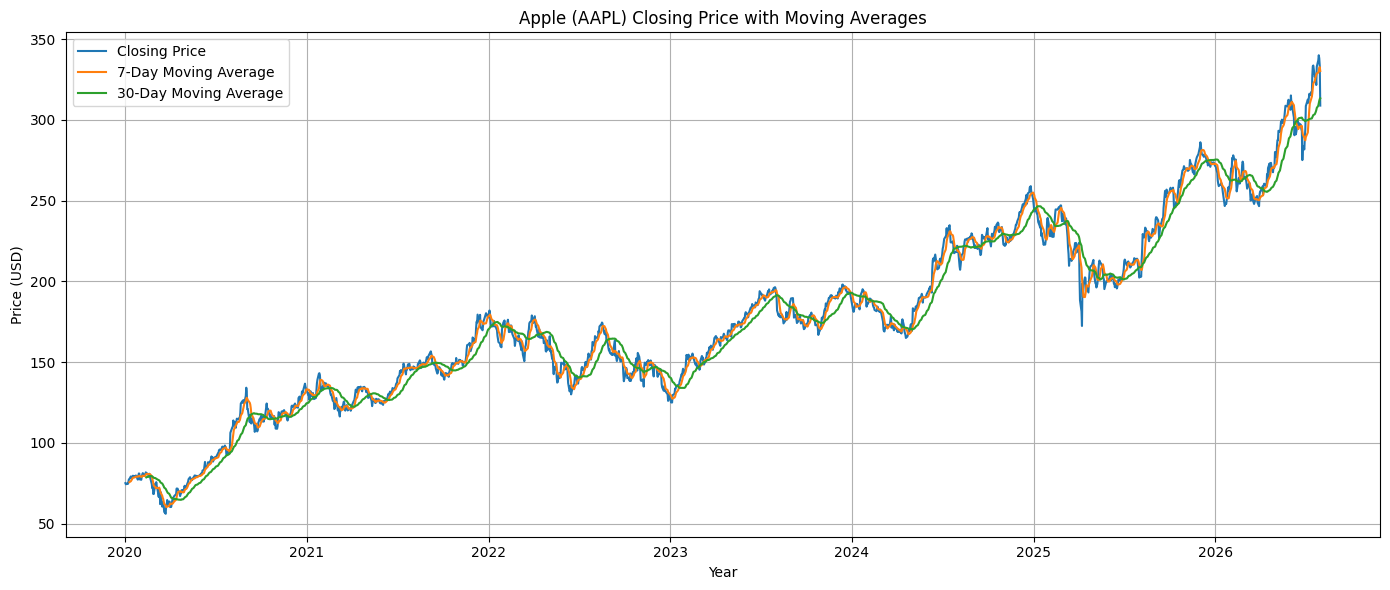

In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"], label="Closing Price")
plt.plot(df.index, df["MA_7"], label="7-Day Moving Average")
plt.plot(df.index, df["MA_30"], label="30-Day Moving Average")

plt.title("Apple (AAPL) Closing Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price (USD)")

# Display years clearly on the X-axis
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of the Closing Price and Moving Average Chart

The visualization shows a clear long-term upward trend in Apple's stock
price between 2020 and 2026, although the overall trend contains several
periods of significant increases and declines.

The stock price initially traded around $75 in early 2020 and experienced
substantial growth over the following years. The price reached levels above
$300 during 2026, demonstrating significant long-term appreciation.

The 7-day moving average follows the closing price more closely and reacts
quickly to short-term changes. In contrast, the 30-day moving average is
smoother and provides a clearer representation of the longer-term trend.

Several periods of increased volatility can also be observed where the
closing price moves sharply away from the moving averages.

Overall, the chart indicates strong long-term growth in Apple's stock
price, while also demonstrating that the stock experienced substantial
short-term fluctuations throughout the period.

### 6.5 Trading Volume Analysis

Trading volume represents the number of Apple shares exchanged during each
trading session.

Analyzing volume alongside stock prices can help identify periods of
increased market activity. Large changes in trading volume may occur during
important market events, major price movements, or periods of increased
investor interest.

In this section, we will examine the overall trading volume and identify
the days with the highest trading activity.

In [34]:
average_volume = df["Volume"].mean()
maximum_volume = df["Volume"].max()
minimum_volume = df["Volume"].min()

print(f"Average Daily Trading Volume: {average_volume:,.0f} shares")
print(f"Maximum Trading Volume: {maximum_volume:,.0f} shares")
print(f"Minimum Trading Volume: {minimum_volume:,.0f} shares")

Average Daily Trading Volume: 81,609,278 shares
Maximum Trading Volume: 426,510,000 shares
Minimum Trading Volume: 17,910,600 shares


### Identifying the Highest-Volume Trading Days

The dataset will be sorted by trading volume to identify the days with the
highest number of shares traded.

This helps highlight periods when Apple experienced unusually high market
activity.

In [35]:
top_volume_days = df[["Close", "Volume"]].sort_values(
    by="Volume",
    ascending=False
).head(10)

top_volume_days

Price,Close,Volume
Date,,
2020-02-28,68.339996,426510000
2020-03-12,62.057499,418474000
2020-03-20,57.310001,401693200
2020-07-31,106.260002,374336800
2020-03-13,69.492500,370732000
2020-08-24,125.857498,345937600
2020-03-02,74.702499,341397200
2020-08-21,124.370003,338054800
2020-03-23,56.092499,336752800


## 7. Trading Volume Analysis

Trading volume measures the number of shares traded during each trading day. Analyzing volume helps identify periods of unusually high or low market activity and can provide additional context when interpreting major price movements.

The analysis calculated the average, maximum, and minimum daily trading volume and identified the days with the highest trading activity.

### Key Findings

- The **average daily trading volume** was approximately **81.61 million shares**.
- The **highest trading volume** was **426.51 million shares**, recorded on **February 28, 2020**.
- The **lowest trading volume** was approximately **17.91 million shares**.
- Several of the highest-volume trading days occurred in **2020**, indicating unusually strong market activity during that period.
- The high-volume dates can be useful for investigating periods of significant market movement and volatility.

### Interpretation

The concentration of extremely high trading volumes in 2020 suggests that the market experienced periods of heightened investor activity. These volume spikes can be associated with major market events and substantial changes in investor sentiment.

Overall, trading volume provides an important complementary indicator to price analysis, helping identify periods when market activity was particularly intense.

## 7. Volatility Analysis

Volatility measures how much the stock price fluctuates over time. In this analysis, daily percentage changes are used to examine Apple's price volatility.

The analysis will:
- Calculate the standard deviation of daily returns.
- Identify periods with unusually high price fluctuations.
- Examine the relationship between volatility and major price movements.

A higher standard deviation indicates greater price volatility and therefore greater short-term price uncertainty.

In [36]:
# Calculate overall daily return volatility
daily_volatility = df['Daily_Pct_Change'].std()

print(f"Daily Return Volatility: {daily_volatility:.2f}%")

# Identify the days with the largest absolute price movements
most_volatile_days = (
    df[['Close', 'Daily_Pct_Change']]
    .dropna()
    .assign(Absolute_Change=lambda x: x['Daily_Pct_Change'].abs())
    .sort_values('Absolute_Change', ascending=False)
    .head(10)
)

print("\nTop 10 Most Volatile Trading Days:")
display(most_volatile_days[['Close', 'Daily_Pct_Change']])

Daily Return Volatility: 1.98%

Top 10 Most Volatile Trading Days:


Price,Close,Daily_Pct_Change
Date,,
2025-04-09,198.850006,15.328853
2020-03-16,60.552502,-12.864696
2020-03-13,69.492500,11.980827
2020-07-31,106.260002,10.468863
2020-03-24,61.720001,10.032540
2020-03-12,62.057499,-9.875467
2020-03-02,74.702499,9.310072
2025-04-03,203.190002,-9.245610
2022-11-10,146.869995,8.897457


### Volatility Findings

The analysis shows that Apple's average daily return volatility was **1.98%**, indicating that the stock typically experienced relatively small day-to-day price fluctuations, although some periods experienced much larger movements.

The most volatile trading day was **April 9, 2025**, when the closing price increased by **15.33%**. The largest daily decline occurred on **March 16, 2020**, when the closing price fell by **12.86%**.

Several of the most volatile days occurred in **March 2020**, indicating a period of significant market uncertainty and sharp price movements. Other notable high-volatility periods occurred in **2025**.

Overall, the results show that while Apple's stock generally had moderate daily volatility, certain market periods produced exceptionally large price movements.

## 8. Yearly Performance Analysis

This analysis examines Apple's stock performance across different years.

The yearly analysis will calculate:
- Average closing price
- Highest closing price
- Lowest closing price
- Average trading volume
- Total trading volume

Comparing these measures across years will help identify periods of strong price growth, declines, and changes in trading activity.

In [37]:
# Yearly performance summary

yearly_summary = df.groupby('Year').agg(
    Average_Close=('Close', 'mean'),
    Highest_Close=('Close', 'max'),
    Lowest_Close=('Close', 'min'),
    Average_Volume=('Volume', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()

yearly_summary

,Year,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume
0,2020,95.347075,136.690002,56.092499,1.575646e+08,39863855600
1,2021,140.989365,180.330002,116.360001,9.052463e+07,22812206100
2,2022,154.835060,182.009995,126.040001,8.791038e+07,22065504500
3,2023,172.549000,198.110001,125.019997,5.922355e+07,14805886900
4,2024,207.205912,259.019989,165.000000,5.710678e+07,14390908500
5,2025,232.240520,286.190002,172.419998,5.417578e+07,13543944600
6,2026,280.688965,340.079987,246.630005,5.115745e+07,7417830200


### Yearly Performance Findings

The yearly analysis shows a clear long-term upward trend in Apple's average closing price.

- The average closing price increased from **$95.35 in 2020** to **$280.69 in 2026**, indicating substantial growth over the analysis period.
- The highest annual closing price recorded was **$340.08 in 2026**, while the lowest was **$56.09 in 2020**.
- Average trading volume was highest in **2020**, at approximately **157.6 million shares per trading day**.
- Trading volume generally declined over the years, reaching an average of approximately **51.2 million shares per day in 2026**.
- Despite the decline in trading volume, Apple's average closing price continued to increase, suggesting strong price appreciation over the period.

Overall, the results indicate strong long-term price growth accompanied by a substantial reduction in average daily trading volume.

## 9. Year-over-Year Price Growth

To better understand Apple's annual performance, we calculate the percentage change in the average closing price from one year to the next.

This helps identify:
- Years with the strongest price growth
- Years with slower growth or declines
- Changes in Apple's overall performance over time

In [38]:
# Calculate year-over-year growth in average closing price

yearly_summary['YoY_Growth_%'] = yearly_summary['Average_Close'].pct_change() * 100

yearly_summary

,Year,Average_Close,Highest_Close,Lowest_Close,Average_Volume,Total_Volume,YoY_Growth_%
0,2020,95.347075,136.690002,56.092499,1.575646e+08,39863855600,NaN
1,2021,140.989365,180.330002,116.360001,9.052463e+07,22812206100,47.869628
2,2022,154.835060,182.009995,126.040001,8.791038e+07,22065504500,9.820382
3,2023,172.549000,198.110001,125.019997,5.922355e+07,14805886900,11.440523
4,2024,207.205912,259.019989,165.000000,5.710678e+07,14390908500,20.085258
5,2025,232.240520,286.190002,172.419998,5.417578e+07,13543944600,12.081995
6,2026,280.688965,340.079987,246.630005,5.115745e+07,7417830200,20.861323


### Year-over-Year Growth Findings

The year-over-year analysis shows that Apple's average closing price increased every year from 2021 through 2026.

- **2021** recorded the strongest annual growth at **47.87%**, showing a significant increase from the 2020 average.
- Growth slowed considerably in **2022**, with an increase of **9.82%**.
- **2023** recorded moderate growth of **11.44%**.
- Growth accelerated in **2024**, reaching **20.09%**.
- **2025** experienced slower growth of **12.08%**.
- **2026** recorded another strong increase of **20.86%**.

Overall, the results indicate a consistent long-term upward trend in Apple's average closing price, although the rate of growth varied considerably between years.

## 10. Best and Worst Performing Years

To identify the strongest and weakest annual performance, we will compare the year-over-year growth rates calculated above.

This will help determine:
- The year with the highest growth
- The year with the lowest growth
- How Apple's annual performance varied throughout the period

In [39]:
# Identify the best and worst performing years

best_year = yearly_summary.loc[
    yearly_summary['YoY_Growth_%'].idxmax()
]

worst_year = yearly_summary.loc[
    yearly_summary['YoY_Growth_%'].idxmin()
]

print(f"Best Performing Year: {int(best_year['Year'])}")
print(f"YoY Growth: {best_year['YoY_Growth_%']:.2f}%")

print(f"\nLowest Growth Year: {int(worst_year['Year'])}")
print(f"YoY Growth: {worst_year['YoY_Growth_%']:.2f}%")

Best Performing Year: 2021
YoY Growth: 47.87%

Lowest Growth Year: 2022
YoY Growth: 9.82%


### Best and Worst Performing Years

The comparison of year-over-year growth identifies **2021 as the best-performing year**, with the average closing price increasing by **47.87%** compared with 2020.

The **lowest growth occurred in 2022**, when the average closing price increased by **9.82%** compared with 2021.

Although 2022 had the lowest growth rate, the stock still recorded positive year-over-year growth. This indicates that Apple's average closing price continued to increase throughout the entire period analyzed.

Overall, **2021 stands out as the strongest year for price growth**, while **2022 represents the slowest period of annual growth**.

## 11. Yearly Average Closing Price Visualization

A line chart will be used to visualize the average closing price across the years.

This visualization will help show the overall long-term price trend and make it easier to identify periods of rapid growth or slower growth.

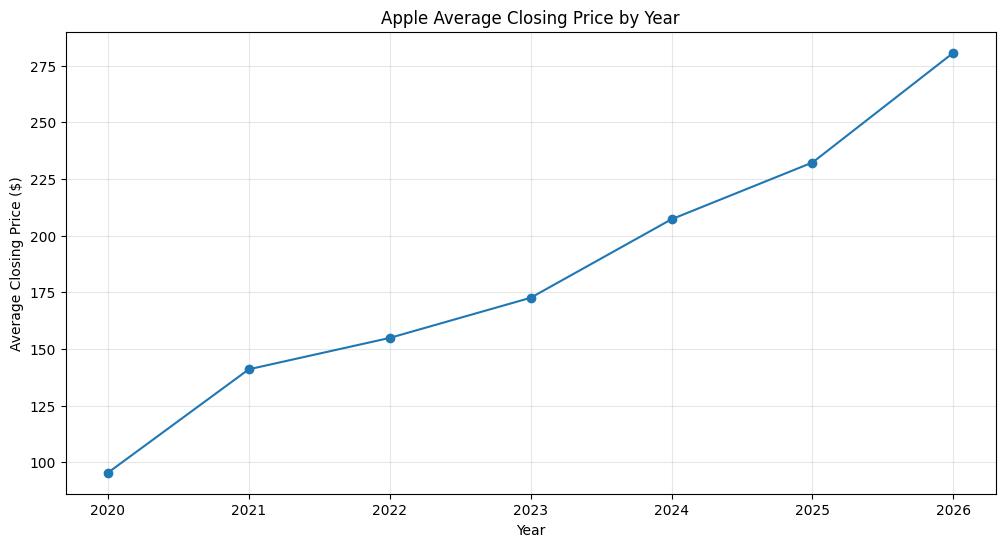

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_summary['Year'],
    yearly_summary['Average_Close'],
    marker='o'
)

plt.title('Apple Average Closing Price by Year')
plt.xlabel('Year')
plt.ylabel('Average Closing Price ($)')
plt.grid(True, alpha=0.3)

plt.show()

### Yearly Average Closing Price Findings

The visualization shows a clear and consistent upward trend in Apple's average closing price from **2020 to 2026**.

The average closing price increased from approximately **$95.35 in 2020** to **$280.69 in 2026**. The largest increase in the trend occurred between **2020 and 2021**, consistent with the **47.87% year-over-year growth** identified earlier.

Although the rate of growth varied across individual years, the overall direction remained positive throughout the analysis period.

This visualization supports the earlier numerical findings that Apple experienced substantial long-term price appreciation between 2020 and 2026.

## 12. Trading Volume Trend

Trading volume represents the number of shares traded during a period.

This analysis examines the yearly average trading volume to determine whether trading activity increased or decreased over the study period.

Understanding volume alongside price performance can provide additional insight into changes in market activity and investor participation.

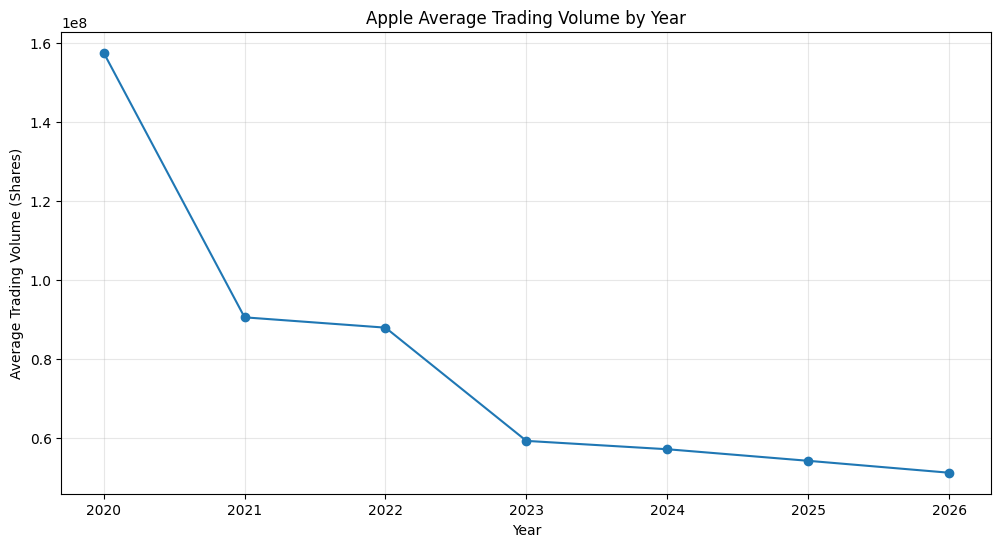

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_summary['Year'],
    yearly_summary['Average_Volume'],
    marker='o'
)

plt.title('Apple Average Trading Volume by Year')
plt.xlabel('Year')
plt.ylabel('Average Trading Volume (Shares)')

plt.xticks(yearly_summary['Year'])

plt.grid(True, alpha=0.3)

plt.show()

### Trading Volume Trend

- Trading volume was exceptionally high in **2020**, with an average daily trading volume of approximately **157.6 million shares**.
- The highest trading activity occurred during **2020**, particularly around the period of significant market volatility, with several days exceeding **300 million shares** traded.
- From 2021 onward, average trading volume showed a clear **long-term downward trend**, despite fluctuations in individual years.
- Average daily volume declined from approximately **90.5 million shares in 2021** to **51.2 million shares in 2026**.
- Despite the decline in average volume, the stock price continued to increase substantially over the same period, suggesting that higher prices were not necessarily accompanied by higher trading activity.
- The chart highlights a major difference between the **2020 high-volume period** and the relatively lower-volume trading environment observed in subsequent years.
- Overall, trading activity became more moderate over time, while the stock demonstrated strong long-term price appreciation.

## 13. Price vs Trading Volume Analysis

Trading volume represents the number of shares traded during a trading period, while daily price change measures the percentage movement in the stock's closing price.

This analysis examines the relationship between trading volume and daily price changes to determine whether significant price movements tend to occur alongside unusually high trading activity.

Understanding this relationship can help identify periods of increased market participation and assess whether trading volume is associated with stronger price movements.

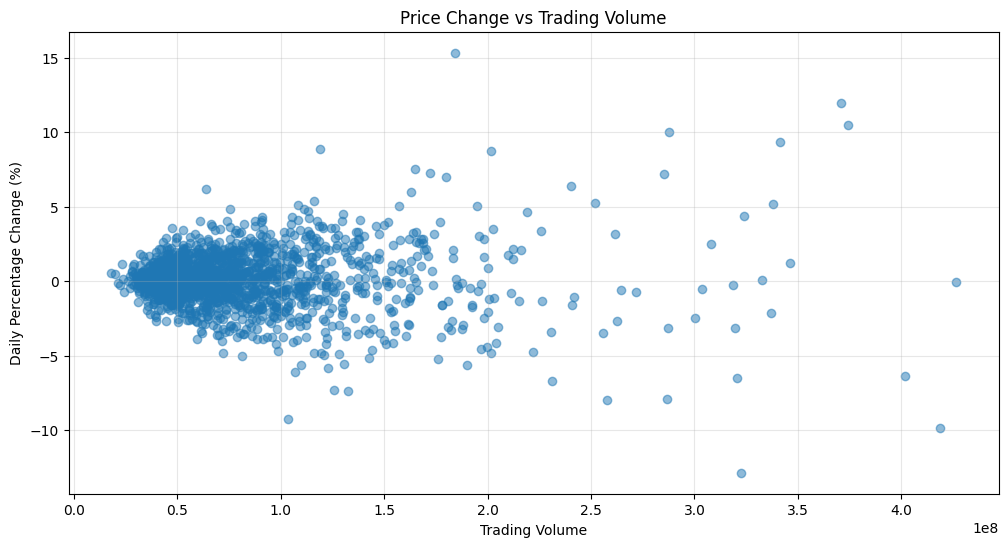

In [42]:
# Price vs Trading Volume Analysis

plt.figure(figsize=(12, 6))

plt.scatter(
    df['Volume'],
    df['Daily_Pct_Change'],
    alpha=0.5
)

plt.xlabel('Trading Volume')
plt.ylabel('Daily Percentage Change (%)')
plt.title('Price Change vs Trading Volume')
plt.grid(True, alpha=0.3)

plt.show()

In [43]:
# Calculate correlation between volume and daily returns

correlation = df['Volume'].corr(df['Daily_Pct_Change'])

print(f"Correlation between Trading Volume and Daily Return: {correlation:.4f}")

Correlation between Trading Volume and Daily Return: 0.0007


### Findings

- The correlation between trading volume and daily returns is **0.0007**, indicating an almost negligible linear relationship.
- The scatter plot shows that daily price movements are widely distributed across different trading volumes.
- Extremely high-volume trading days can coincide with both large gains and large losses, suggesting that high volume does not consistently predict the direction of price movements.
- Overall, trading volume alone does not appear to be a strong predictor of daily price returns for Apple stock during the study period.

## 14. Monthly Price Performance

Monthly price performance provides a broader view of stock movements by aggregating daily closing prices into monthly measures.

This analysis examines the average monthly closing price and monthly percentage returns to identify periods of stronger or weaker performance.

Understanding monthly trends can help reveal seasonal patterns and longer-term changes that may not be immediately visible in daily price movements.

In [44]:
# Monthly Price Performance

monthly_performance = df.copy()

monthly_performance['Year'] = monthly_performance.index.year
monthly_performance['Month'] = monthly_performance.index.month

monthly_summary = monthly_performance.groupby(
    ['Year', 'Month']
).agg(
    Average_Close=('Close', 'mean'),
    Highest_Close=('Close', 'max'),
    Lowest_Close=('Close', 'min')
).reset_index()

monthly_summary['Monthly_Return_%'] = (
    monthly_summary['Average_Close']
    .pct_change() * 100
)

monthly_summary.head(12)

,Year,Month,Average_Close,Highest_Close,Lowest_Close,Monthly_Return_%
0,2020,1,77.979048,81.084999,74.357498,NaN
1,2020,2,77.817631,81.800003,68.339996,-0.207001
2,2020,3,65.611023,75.684998,56.092499,-15.686172
3,2020,4,68.096547,73.449997,60.227501,3.788272
4,2020,5,77.496376,79.807503,72.267502,13.803679
5,2020,6,86.451590,91.632500,80.462502,11.555656
6,2020,7,95.566250,106.260002,91.027496,10.543079
7,2020,8,117.299762,129.039993,108.937500,22.741828
8,2020,9,115.125237,134.179993,106.839996,-1.853819
9,2020,10,116.413182,124.400002,108.860001,1.118735


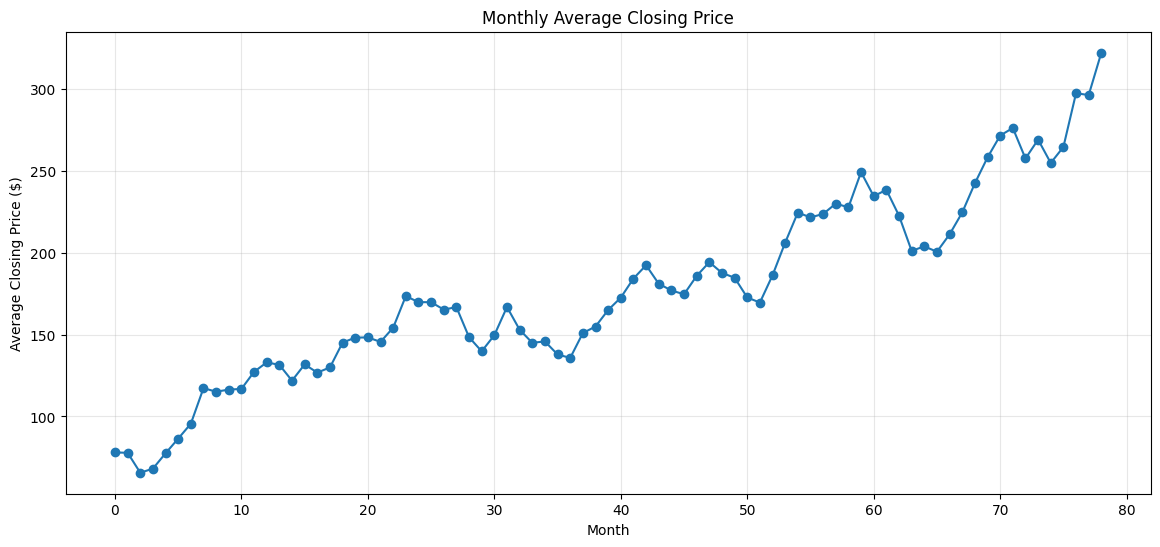

In [45]:
# Plot Monthly Average Closing Price

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_summary.index,
    monthly_summary['Average_Close'],
    marker='o'
)

plt.title('Monthly Average Closing Price')
plt.xlabel('Month')
plt.ylabel('Average Closing Price ($)')
plt.grid(True, alpha=0.3)

plt.show()

### Findings

- Apple's average monthly closing price shows a strong overall upward trend throughout the study period.
- The stock experienced several temporary declines, particularly during periods of increased market volatility, but generally recovered and continued to rise.
- The average monthly closing price increased from approximately **$78 in early 2020** to above **$280 by 2026**, demonstrating substantial long-term price appreciation.
- The strongest upward movements are visible in the later years, particularly from 2024 onward.
- Overall, the monthly analysis confirms the long-term growth pattern observed in the daily and yearly analyses.

## 15. Monthly Return Analysis

Monthly returns measure the percentage change in Apple's average closing price from one month to the next.

This analysis helps identify months with particularly strong positive or negative performance and provides a clearer view of short-term periods of growth and decline.

Examining monthly returns alongside the long-term price trend can help highlight periods of increased market performance and volatility.

In [46]:
# Recreate Monthly Summary

monthly_performance = df.copy()

monthly_performance['Year'] = monthly_performance.index.year
monthly_performance['Month'] = monthly_performance.index.month

monthly_summary = monthly_performance.groupby(
    ['Year', 'Month']
).agg(
    Average_Close=('Close', 'mean'),
    Highest_Close=('Close', 'max'),
    Lowest_Close=('Close', 'min')
).reset_index()

monthly_summary.head()

,Year,Month,Average_Close,Highest_Close,Lowest_Close
0,2020,1,77.979048,81.084999,74.357498
1,2020,2,77.817631,81.800003,68.339996
2,2020,3,65.611023,75.684998,56.092499
3,2020,4,68.096547,73.449997,60.227501
4,2020,5,77.496376,79.807503,72.267502


In [47]:
# Monthly Return Analysis

monthly_summary['Monthly_Return_%'] = (
    monthly_summary['Average_Close'].pct_change() * 100
)

highest_monthly_return = monthly_summary.loc[
    monthly_summary['Monthly_Return_%'].idxmax()
]

lowest_monthly_return = monthly_summary.loc[
    monthly_summary['Monthly_Return_%'].idxmin()
]

print("Highest Monthly Return:")
print(highest_monthly_return)

print("\nLowest Monthly Return:")
print(lowest_monthly_return)

Highest Monthly Return:
Year                2020.000000
Month                  8.000000
Average_Close        117.299762
Highest_Close        129.039993
Lowest_Close         108.937500
Monthly_Return_%      22.741828
Name: 7, dtype: float64

Lowest Monthly Return:
Year                2020.000000
Month                  3.000000
Average_Close         65.611023
Highest_Close         75.684998
Lowest_Close          56.092499
Monthly_Return_%     -15.686172
Name: 2, dtype: float64


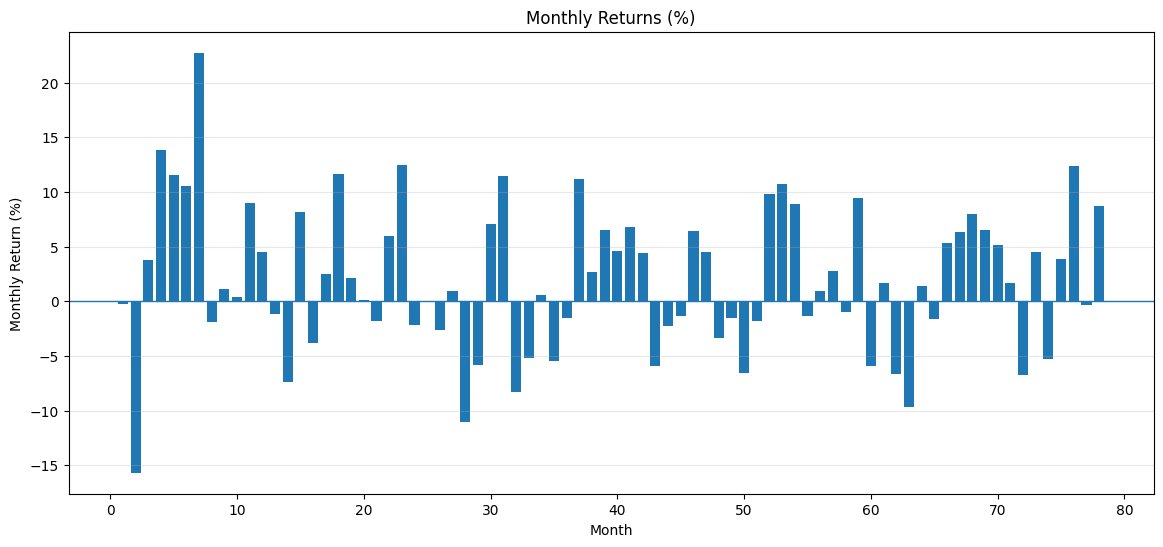

In [48]:
# Plot Monthly Returns

plt.figure(figsize=(14, 6))

plt.bar(
    monthly_summary.index,
    monthly_summary['Monthly_Return_%']
)

plt.axhline(0, linewidth=1)

plt.title('Monthly Returns (%)')
plt.xlabel('Month')
plt.ylabel('Monthly Return (%)')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

## 14. Monthly Return Analysis

Monthly returns measure the percentage change in the average closing price from one month to the next.

This analysis helps identify the strongest and weakest months in Apple's stock performance and highlights periods of significant positive or negative price movement.

### Key Findings

- The **highest monthly return** was recorded in **August 2020**, with a return of **22.74%**.
- The **lowest monthly return** occurred in **March 2020**, with a return of **-15.69%**.
- Monthly returns fluctuate considerably, with both strong gains and significant declines observed throughout the study period.
- The large negative return in March 2020 reflects a period of substantial market volatility, while the strong recovery in subsequent months demonstrates the stock's ability to rebound.
- Overall, the monthly return analysis shows that Apple's stock experienced periods of significant short-term volatility despite its broader long-term upward price trend.

## 15. Cumulative Return Analysis

Cumulative return measures the overall percentage change in Apple's stock price from the beginning of the study period to each point in time.

This analysis provides a long-term view of investment performance and helps demonstrate the overall growth of Apple's stock throughout the study period.

Final Cumulative Return: 311.40%


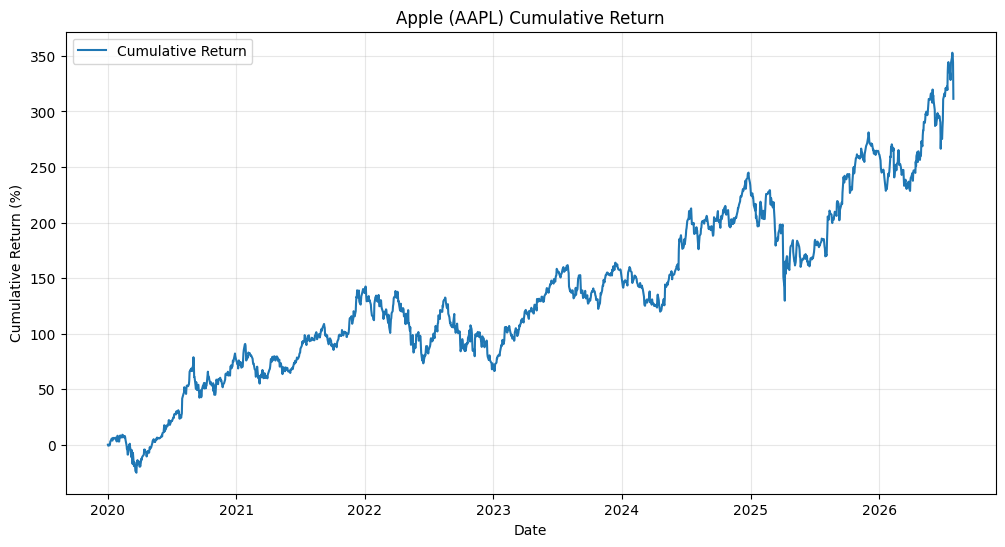

In [49]:
# Calculate cumulative return
df['Cumulative_Return_%'] = (
    (df['Close'] / df['Close'].iloc[0]) - 1
) * 100

# Display the latest cumulative return
print(f"Final Cumulative Return: {df['Cumulative_Return_%'].iloc[-1]:.2f}%")

# Plot cumulative return
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df['Cumulative_Return_%'],
    label='Cumulative Return'
)

plt.title("Apple (AAPL) Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### Key Findings

- Apple's stock achieved a **final cumulative return of 311.40%** over the study period.
- The cumulative return shows a strong long-term upward trend, indicating substantial growth in Apple's stock price.
- The stock experienced several temporary drawdowns, particularly during periods of increased market volatility, but generally recovered and continued its upward trajectory.
- The strongest sustained growth occurred during the later years of the study period, with cumulative returns reaching their highest levels in 2026.
- Overall, the analysis demonstrates strong long-term price appreciation despite short-term fluctuations and market volatility.

## 16. Drawdown Analysis

Drawdown measures the percentage decline in Apple's stock price from a previous peak to a subsequent low.

This analysis helps identify periods of significant price declines and assess the downside risk experienced by investors throughout the study period.

By examining drawdowns, we can understand how severe temporary losses were and how the stock recovered from major declines.

Maximum Drawdown: -33.43%


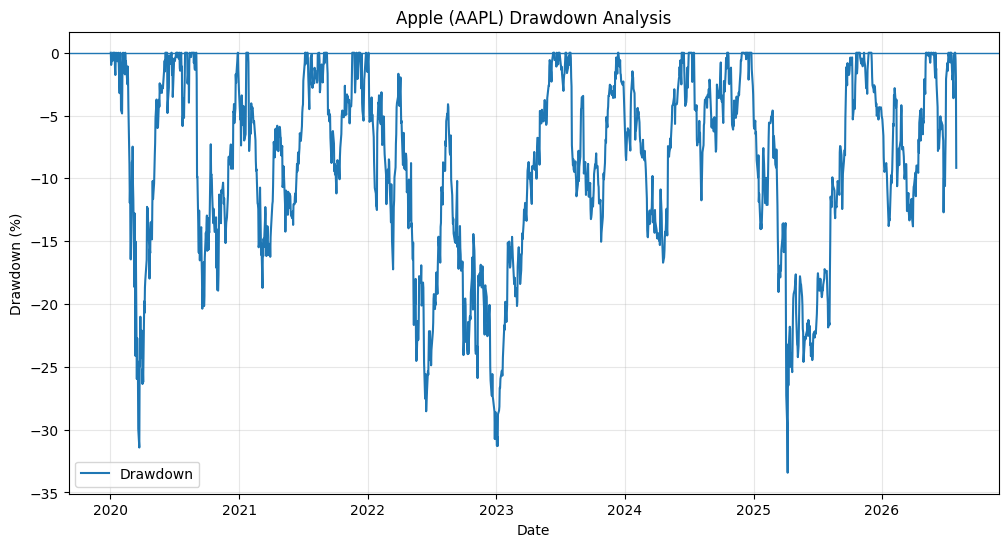

In [50]:
# Calculate running maximum of closing price
df['Running_Max'] = df['Close'].cummax()

# Calculate drawdown percentage
df['Drawdown_%'] = (
    (df['Close'] - df['Running_Max']) / df['Running_Max']
) * 100

# Find maximum drawdown
max_drawdown = df['Drawdown_%'].min()

print(f"Maximum Drawdown: {max_drawdown:.2f}%")

# Plot drawdown
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df['Drawdown_%'],
    label='Drawdown'
)

plt.axhline(0, linewidth=1)

plt.title("Apple (AAPL) Drawdown Analysis")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

### Key Findings

- Apple's **maximum drawdown was -33.43%**, representing the largest decline from a previous peak during the study period.
- The drawdown chart shows several periods of substantial declines, demonstrating that Apple's stock experienced significant short-term downside risk despite its strong long-term growth.
- The most severe drawdown occurred around **2025**, when the stock experienced a decline of more than 30% from its previous peak.
- Several other notable drawdowns occurred during **2020, 2022, and 2023**, reflecting periods of increased market uncertainty and volatility.
- Despite these declines, the stock repeatedly recovered toward previous highs, contributing to the strong **311.40% cumulative return** observed over the full study period.
- Overall, the analysis demonstrates that strong long-term returns can occur alongside significant temporary losses and periods of elevated downside risk.

## 17. Correlation Analysis

Correlation analysis measures the strength and direction of relationships between numerical variables in the dataset.

This analysis examines how Apple's closing price, trading volume, daily price change, daily percentage change, and daily trading range are related to one another.

Understanding these relationships can help identify variables that tend to move together and provide additional insight into Apple's stock market behavior.

Correlation Matrix:


Price,Close,Volume,Daily_Price_Change,Daily_Pct_Change,Daily_Range
Price,,,,,
Close,1.000,-0.609,0.040,0.013,0.408
Volume,-0.609,1.000,-0.010,0.001,0.122
Daily_Price_Change,0.040,-0.010,1.000,0.923,-0.030
Daily_Pct_Change,0.013,0.001,0.923,1.000,-0.027
Daily_Range,0.408,0.122,-0.030,-0.027,1.000


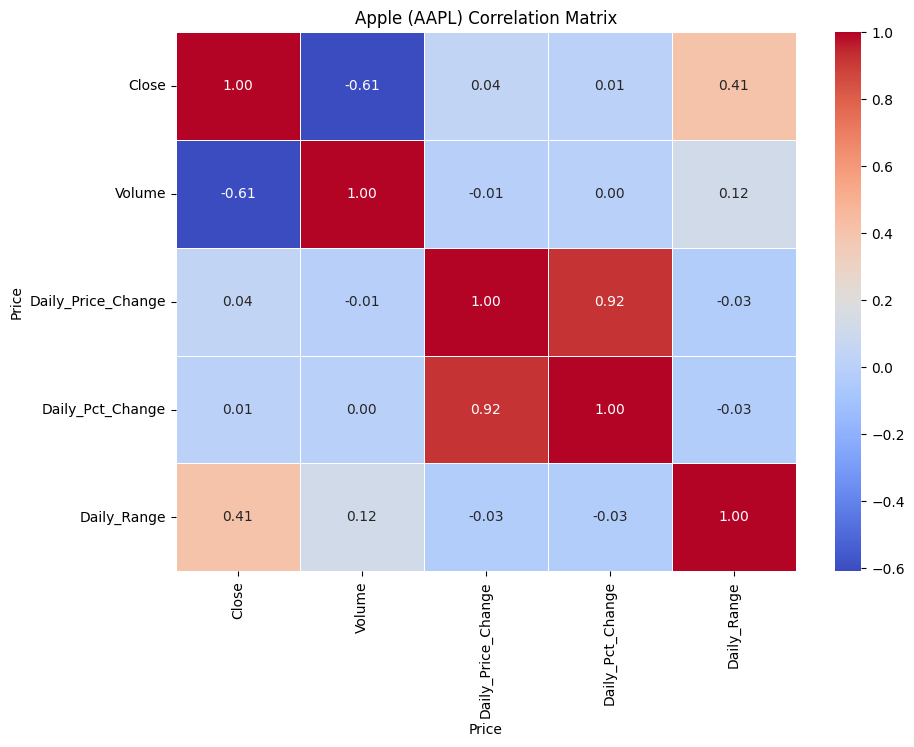

In [53]:
# Select numerical variables for correlation analysis
correlation_data = df[
    ['Close', 'Volume', 'Daily_Price_Change',
     'Daily_Pct_Change', 'Daily_Range']
]

# Calculate correlation matrix
correlation_matrix = correlation_data.corr()

# Display correlation matrix
print("Correlation Matrix:")
display(correlation_matrix.round(3))

# Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Apple (AAPL) Correlation Matrix")
plt.show()

In [52]:
import seaborn as sns

### Key Findings

- Closing Price and Trading Volume show a **moderate negative correlation of -0.61**, indicating that higher closing prices generally coincided with lower trading volumes over the study period.
- Daily Price Change and Daily Percentage Change have a **strong positive correlation of 0.92**, which is expected because both variables measure daily price movement using closely related calculations.
- Closing Price and Daily Trading Range have a **moderate positive correlation of 0.41**, suggesting that larger price ranges tended to occur when Apple's stock price was higher.
- Trading Volume has almost **no correlation with Daily Percentage Change (0.001)**, indicating that daily trading volume alone did not have a meaningful linear relationship with daily percentage returns.
- Daily Trading Range also shows very weak relationships with Daily Price Change (-0.03) and Daily Percentage Change (-0.03).
- Overall, the correlation analysis shows that some variables have strong mathematical or structural relationships, while trading volume has limited linear association with short-term daily returns.

## 18. Risk-Return Analysis

Risk-return analysis examines the relationship between investment returns and the level of volatility experienced during the study period.

This analysis helps evaluate Apple's stock performance by considering both its return potential and the variability of its daily returns.

In [54]:
# Calculate risk and return metrics

average_daily_return = df['Daily_Pct_Change'].mean()
daily_volatility = df['Daily_Pct_Change'].std()

# Annualized metrics
annualized_return = average_daily_return * 252
annualized_volatility = daily_volatility * (252 ** 0.5)

# Risk-adjusted return (Sharpe-like ratio, assuming 0% risk-free rate)
risk_return_ratio = annualized_return / annualized_volatility

print(f"Average Daily Return: {average_daily_return:.2f}%")
print(f"Daily Volatility: {daily_volatility:.2f}%")
print(f"Annualized Return: {annualized_return:.2f}%")
print(f"Annualized Volatility: {annualized_volatility:.2f}%")
print(f"Risk-Return Ratio: {risk_return_ratio:.2f}")

Average Daily Return: 0.11%
Daily Volatility: 1.98%
Annualized Return: 26.53%
Annualized Volatility: 31.50%
Risk-Return Ratio: 0.84


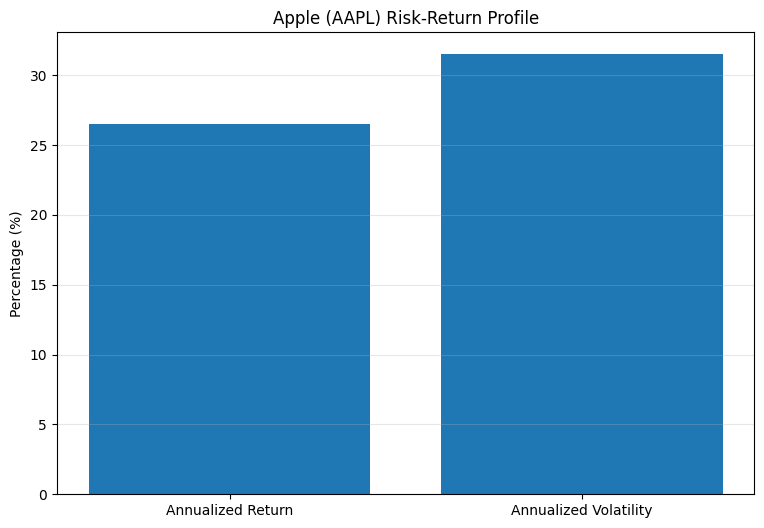

In [55]:
# Create Risk-Return visualization

metrics = pd.DataFrame({
    'Metric': ['Annualized Return', 'Annualized Volatility'],
    'Value': [annualized_return, annualized_volatility]
})

plt.figure(figsize=(9, 6))

plt.bar(metrics['Metric'], metrics['Value'])

plt.title("Apple (AAPL) Risk-Return Profile")
plt.ylabel("Percentage (%)")
plt.grid(axis='y', alpha=0.3)

plt.show()

### Key Findings

- **Average Daily Return:** 0.11%
- **Daily Volatility:** 1.98%
- **Annualized Return:** 26.53%
- **Annualized Volatility:** 31.50%
- **Risk-Return Ratio:** 0.84

The analysis shows that Apple generated a strong **annualized return of 26.53%**, but this was accompanied by relatively high **annualized volatility of 31.50%**.

The **risk-return ratio of 0.84** indicates that the investment generated approximately 0.84 units of annualized return for every unit of annualized volatility. Overall, the stock demonstrated strong growth potential while also carrying a significant level of market risk.

## 17. Key Findings & Insights

The analysis of Apple (AAPL) historical stock data from 2020 to 2026 revealed several important patterns in price performance, trading activity, volatility, and risk.

### 1. Strong Long-Term Price Growth

Apple's average closing price increased substantially throughout the study period, rising from approximately $95.35 in 2020 to $280.69 in 2026.

The yearly analysis shows a generally upward trend in Apple's stock price despite periods of short-term declines and market volatility.

### 2. Positive Year-over-Year Growth

The strongest year-over-year growth in average closing price occurred in 2021, with a growth rate of approximately 47.87%.

The lowest positive growth occurred in 2022 at approximately 9.82%. Despite being the weakest growth year, the stock still maintained positive year-over-year growth.

### 3. Declining Trading Volume

Average daily trading volume decreased considerably over the study period.

Average trading volume was approximately 157.6 million shares in 2020 compared with approximately 51.2 million shares in 2026. This indicates that trading activity generally declined even as Apple's stock price increased.

### 4. High Market Volatility

The average daily return volatility was approximately 1.98%, while the annualized volatility was approximately 31.50%.

Several periods experienced significant daily price movements. The largest positive daily return was approximately 15.33%, while the largest negative daily return was approximately -12.86%.

### 5. Strong Monthly Performance in August 2020

The highest monthly return in the dataset occurred in August 2020, with a return of approximately 22.74%.

The lowest monthly return occurred in March 2020, at approximately -15.69%, highlighting the significant market disruption and volatility during that period.

### 6. Strong Cumulative Performance

The cumulative return over the study period reached approximately 311.40%.

This indicates that despite significant short-term fluctuations and periods of substantial drawdowns, Apple's stock generated strong long-term growth over the analyzed period.

### 7. Significant Drawdowns

The maximum drawdown was approximately -33.43%.

This demonstrates that investors experienced periods where the stock declined substantially from previous peak levels before recovering.

### 8. Weak Relationship Between Trading Volume and Daily Returns

The correlation between trading volume and daily percentage returns was approximately 0.0007.

This is extremely close to zero, suggesting that there was virtually no linear relationship between daily trading volume and daily returns in this dataset.

### 9. Risk–Return Profile

Apple recorded an annualized return of approximately 26.53% compared with annualized volatility of approximately 31.50%.

The resulting risk-return ratio was approximately 0.84, indicating that the stock generated strong returns but also carried a relatively high level of price volatility.

### Overall Finding

Overall, the analysis shows that Apple demonstrated strong long-term price appreciation between 2020 and 2026. However, this growth was accompanied by considerable volatility and significant drawdowns.

The results also show that increasing stock prices did not necessarily correspond with increasing trading volume, while daily trading volume had almost no linear relationship with daily returns.

## 18. Recommendations & Interpretation

Based on the findings from the analysis, the following recommendations can be made:

### 1. Consider Long-Term Investment Perspective

The strong cumulative return of approximately 311.40% and the consistent long-term increase in Apple's average closing price suggest that AAPL demonstrated strong historical growth over the study period.

Investors evaluating the stock should therefore consider its long-term performance rather than focusing only on short-term price movements.

### 2. Account for Market Volatility

Although Apple generated strong historical returns, the annualized volatility was approximately 31.50% and the maximum drawdown reached approximately -33.43%.

Investors should therefore be prepared for significant short-term fluctuations and potential temporary losses.

### 3. Monitor Risk Alongside Returns

The annualized return of approximately 26.53% was accompanied by annualized volatility of 31.50%, resulting in a risk-return ratio of approximately 0.84.

This indicates that strong returns were achieved with a relatively high level of risk. Investment decisions should therefore consider both expected returns and the level of volatility required to achieve them.

### 4. Do Not Rely on Trading Volume Alone

The correlation between trading volume and daily returns was approximately 0.0007, indicating an almost nonexistent linear relationship.

Trading volume should therefore not be used as a standalone indicator for predicting daily stock returns. It should instead be evaluated alongside price trends, volatility, market conditions, and other financial indicators.

### 5. Use Drawdowns to Understand Risk

The maximum drawdown of approximately -33.43% demonstrates that even a strong-performing stock can experience substantial declines.

Investors should consider their risk tolerance and investment horizon before making decisions based solely on historical performance.

### 6. Consider Market Conditions

The analysis identified periods of particularly high volatility, including March 2020 and April 2025.

This highlights the importance of considering broader market and economic conditions when interpreting stock performance rather than attributing all price movements to company-specific factors.

### Overall Recommendation

Apple's historical performance demonstrates strong long-term growth potential, but the stock also exhibits substantial volatility and drawdown risk.

A balanced investment approach should therefore consider both the stock's historical growth and its associated risks. Historical performance should not be treated as a guarantee of future returns, and investment decisions should incorporate broader market conditions and individual risk tolerance.

## 19. Conclusion

This project analyzed Apple's (AAPL) historical stock performance from 2020 to 2026 using Python and Pandas.

The analysis examined stock prices, trading volume, daily and monthly returns, volatility, cumulative performance, drawdowns, correlations, and the overall risk-return profile.

The results demonstrate that Apple experienced strong long-term price growth, with the average closing price increasing from approximately $95.35 in 2020 to $280.69 in 2026. The stock also achieved a cumulative return of approximately 311.40%, demonstrating substantial historical appreciation.

However, the analysis also highlighted significant investment risks. Annualized volatility reached approximately 31.50%, while the maximum drawdown was approximately -33.43%. These results demonstrate that strong long-term returns were accompanied by considerable short-term fluctuations.

Trading activity showed a different pattern, with average daily trading volume declining substantially over the study period. Furthermore, the correlation between trading volume and daily returns was approximately 0.0007, indicating almost no linear relationship between the two variables.

Overall, the analysis provides evidence of Apple's strong historical growth while emphasizing the importance of considering volatility, drawdowns, and market conditions when evaluating stock performance.

This project demonstrates the application of Python-based data analysis techniques to transform historical financial data into meaningful insights that can support data-driven financial analysis.